In [169]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d

class RocketFeatureExtractor:
    def __init__(self, hand="Right", target_fps=10.0, orig_fps=30.0, window_sec=20.0, step_sec=5.0):
        self.hand = hand
        self.target_fps = float(target_fps)
        self.orig_fps = float(orig_fps)
        self.dt_target = 1.0 / self.target_fps
        self.dt_orig = 1.0 / self.orig_fps
        self.window_size = int(window_sec * self.target_fps)  # e.g., 200 for 20s at 10 FPS
        self.step_size = int(step_sec * self.target_fps)

    def _calculate_4_channels(self, dfh):
        # --- 1. Re-index to a strict 30 FPS timeline to expose gaps ---
        min_f, max_f = dfh['frame'].min(), dfh['frame'].max()
        # Create a full index: if frame 10 is followed by frame 50, frames 11-49 will be NaN
        full_idx = np.arange(min_f, max_f + 1)
        df_gap = dfh.set_index('frame').reindex(full_idx).reset_index()

        def get_pts(lm_prefix):
            cols = [f'{lm_prefix}_{ax}_smooth' for ax in ['x', 'y']]
            # We ffill/bfill ONLY for the derivative math so it doesn't break,
            # but we will mask these out later.
            return df_gap[cols].ffill().bfill().fillna(0).values

        pts0 = get_pts('lm_0')   # Wrist
        pts5 = get_pts('lm_5')   # Index
        pts17 = get_pts('lm_17') # Pinky

        # --- 2. Calculate Kinematics at 30 FPS ---
        d_pos = np.diff(pts0, axis=0, prepend=pts0[:1, :])
        v_mag = np.sqrt(np.sum(d_pos**2, axis=1)) / self.dt_orig
        dv = np.diff(v_mag, prepend=v_mag[0]) / self.dt_orig
        a_mag = np.abs(dv) / self.dt_orig
        jerk = np.diff(dv, prepend=dv[0]) / self.dt_orig

        v_orient = pts5 - pts0
        angles = np.arctan2(v_orient[:, 1], v_orient[:, 0])
        d_angle = np.diff(angles, prepend=angles[0])
        d_angle = (d_angle + np.pi) % (2 * np.pi) - np.pi

        v1, v2 = pts5 - pts0, pts17 - pts0
        palm_area = 0.5 * np.abs(v1[:, 0]*v2[:, 1] - v1[:, 1]*v2[:, 0])

        # --- 3. Create Validity Mask (at 30 FPS) ---
        # A frame is valid ONLY if it existed in the original tracking AND landmarks were present
        mask_30 = ~(df_gap['lm_0_x_smooth'].isna() | 
                    df_gap['lm_5_x_smooth'].isna() | 
                    df_gap['lm_17_x_smooth'].isna()).values

        # --- 4. Downsample to 10 FPS ---
        # Instead of slicing [::3], we use a mean resample to be more robust
        channels_30 = np.stack([v_mag, d_angle, palm_area], axis=1)
        
        # Determine number of 10fps steps
        n_steps_10 = int(len(channels_30) * (self.target_fps / self.orig_fps))
        
        # Resample channels and mask to 10 FPS
        x_30 = np.linspace(0, 1, len(channels_30))
        x_10 = np.linspace(0, 1, n_steps_10)
        
        f_chan = interp1d(x_30, channels_30, axis=0, kind='linear', fill_value="extrapolate")
        f_mask = interp1d(x_30, mask_30.astype(float), kind='nearest', fill_value="extrapolate")
        
        channels_10 = f_chan(x_10)
        mask_10 = f_mask(x_10) > 0.5 # Back to boolean

        # --- 5. Apply Mask ---
        # Crucial: Large gaps become zeros. ROCKET kernels will see "flat" 
        # periods where tracking was lost, preserving the temporal duration.
        return channels_10 * mask_10[:, np.newaxis]

    def prepare_rocket_windows(self, df_dict):
        all_windows = []
        video_mapping = [] # To know which window belongs to which video

        for key, df in tqdm(df_dict.items(), desc="Slicing ROCKET Windows"):
            dfh = df[df["hand_label"] == self.hand].copy()
            if len(dfh) < self.window_size: continue
            
            # 1. Get constant 10 FPS channels (using the Gap-Aware logic from before)
            # This returns (T_total, 4) at a fixed 10 FPS
            full_signal = self._calculate_4_channels(dfh) 
            
            # 2. Slice into fixed-size windows
            # No interpolation needed here! Physical units are preserved.
            for start in range(0, len(full_signal) - self.window_size + 1, self.step_size):
                end = start + self.window_size
                window = full_signal[start:end] # (200, 4)
                
                # ROCKET expects (Channels, Time)
                all_windows.append(window.T)
                video_mapping.append(key)
        
        return np.array(all_windows), video_mapping

In [2]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
if os.getcwd().endswith("notebooks"):
    os.chdir("../")

In [3]:
processed_path = "data/processed/landmark_dataframes/"
paths = [os.path.join(processed_path, f) for f in os.listdir(processed_path) if f.endswith("30fps_processed.pkl")]

df_dict = {}
cols_to_keep = ['frame', 'hand_label', 'cx_smooth', 'cy_smooth']

# load df with where first column in csv serves as index
df_vid_name_map = pd.read_csv("data/scores/vid_name_map.csv", index_col=0)

with tqdm(total=len(paths), desc="Loading processed data") as pbar:
    for path in paths:
        vid = os.path.basename(path).replace("_30fps_processed.pkl", "")
        vid = vid.replace("hand_tracking_", "")
        participant_id = df_vid_name_map.loc[vid]['Participant Number']
        if int(participant_id) == 8:
            continue
        df_dict[(vid, int(participant_id))] = pd.read_pickle(path)#[cols_to_keep]
        pbar.update(1)

df_scores = pd.read_csv("data/scores/merged_scores.csv")[['Vid_Name', 'QRS_Overal']]
grs_scores = df_scores.set_index('Vid_Name')['QRS_Overal'].to_dict()

Loading processed data:  97%|█████████▋| 83/86 [00:04<00:00, 17.71it/s]


In [422]:
from sktime.transformations.panel.rocket import MiniRocketMultivariate
from sklearn.linear_model import RidgeCV

# 1. Initialize and Prepare Data
extractor = RocketFeatureExtractor(hand="Right", window_sec=3.0, step_sec=1.0)
X_windows, video_mapping = extractor.prepare_rocket_windows(df_dict)

# 2. Generate ROCKET Features (The "Brute Force" part)
# This will turn your 5 channels into ~10,000 features
rocket = MiniRocketMultivariate(random_state=40)
X_win_feats = rocket.fit_transform(X_windows)

# 3. Predict Residuals
# Let's say 'df_results' contains your MAE 5.0 predictions
# residuals = actual_scores - predicted_scores

# Merge ROCKET features with your residual labels using 'keys'
# and run a Ridge Regression. 
# If the R2 score is > 0.1, you have found a local signal!

Slicing ROCKET Windows: 100%|██████████| 83/83 [00:04<00:00, 16.86it/s]


In [ ]:
"""
df_rocket = pd.DataFrame(X_win_feats)
df_rocket['video_key'] = video_mapping
video_level_rocket = df_rocket.groupby('video_key').max()"""




# 1. Convert to DataFrame
df_win = pd.DataFrame(X_win_feats)
df_win['video_key'] = video_mapping

# 2. Multi-aggregate
# This captures consistency (mean), peak clumsiness (max), and erraticness (std)
video_level_rocket = df_win.groupby('video_key').agg(['mean', 'max', 'std'])
video_level_rocket.columns = [f"{c[0]}_{c[1]}" for c in video_level_rocket.columns]


# smth to try:
# also remember next thing to do is double check expert rating MAE and std!!!

def robust_aggregate(window_features):
    # window_features shape: (num_windows, num_kernels)
    feat_mean = np.mean(window_features, axis=0)
    feat_std  = np.std(window_features, axis=0)
    feat_p95  = np.percentile(window_features, 95, axis=0) # Robust Max
    feat_p10  = np.percentile(window_features, 10, axis=0) # Robust Min/Floor
    
    return np.hstack([feat_mean, feat_std, feat_p95, feat_p10])


In [455]:
video_level_rocket.shape

(83, 29988)

In [424]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

n = 82
# --- 1. Distill ROCKET Features ---
# We use PCA because 10,000 features on 83 samples is "Overfitting Suicide"
pca_rocket = PCA(n_components=n) # Keep top 15 temporal patterns
rocket_pca_features = pca_rocket.fit_transform(StandardScaler().fit_transform(video_level_rocket))

# Convert to DataFrame for merging
df_rocket_pca = pd.DataFrame(
    rocket_pca_features, 
    index=video_level_rocket.index, 
    columns=[f'Rocket_PC{i+1}' for i in range(n)]
)

In [425]:
df_rocket_pca = df_rocket_pca.reset_index()

In [426]:
# load 
df_metrics = pd.read_csv("data/metrics/best_global_metrics2.csv")
df_metrics.head()



,Participant Number,GRS_Total,QRS_Overal,Case_Number,adjusted_total_path_Right,total_duration_Right,num_reversals_Right,velocity_corr,interhand_dist_change_rms,mean_abs_angle_change_Right
0,1,59.25,48.50,1,62034.389107,534.933333,737,0.300569,37.862266,0.726575
1,1,54.40,45.00,2,37353.044239,288.033333,378,0.642479,37.941429,0.899482
2,1,74.50,60.50,3,51364.691660,423.033333,694,0.476772,39.133227,0.929110
3,2,49.25,39.25,1,103592.752300,1281.533333,1571,0.356040,23.805603,0.726725
4,2,49.00,38.00,2,74343.087367,1010.833333,1133,0.475344,21.928832,0.714639


In [427]:
df_combined = pd.merge(df_rocket_pca, df_metrics, left_index=True, right_index=True)

In [428]:

global_features = ['adjusted_total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'velocity_corr']
rocket_features = [f'Rocket_PC{i+1}' for i in range(n)]

# for each of the features correlation with QRS_Overal
for feature in global_features + rocket_features:
    corr = df_combined[feature].corr(df_combined['QRS_Overal'])
    print(f"Correlation between {feature} and QRS_Overal: {corr:.4f}")

Correlation between adjusted_total_path_Right and QRS_Overal: -0.7176
Correlation between total_duration_Right and QRS_Overal: -0.6843
Correlation between num_reversals_Right and QRS_Overal: -0.7203
Correlation between velocity_corr and QRS_Overal: -0.0071
Correlation between Rocket_PC1 and QRS_Overal: 0.0802
Correlation between Rocket_PC2 and QRS_Overal: 0.1907
Correlation between Rocket_PC3 and QRS_Overal: -0.2782
Correlation between Rocket_PC4 and QRS_Overal: -0.0737
Correlation between Rocket_PC5 and QRS_Overal: -0.4548
Correlation between Rocket_PC6 and QRS_Overal: 0.1419
Correlation between Rocket_PC7 and QRS_Overal: -0.4037
Correlation between Rocket_PC8 and QRS_Overal: -0.0190
Correlation between Rocket_PC9 and QRS_Overal: -0.0683
Correlation between Rocket_PC10 and QRS_Overal: 0.1151
Correlation between Rocket_PC11 and QRS_Overal: -0.1998
Correlation between Rocket_PC12 and QRS_Overal: 0.0862
Correlation between Rocket_PC13 and QRS_Overal: 0.0741
Correlation between Rocket_PC1

In [429]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
from matplotlib import pyplot as plt


def candidate_vs_pca_explainability(
    df,
    candidate_features,
    target='QRS_Overal',
    pcs_to_use=[0],
    pca_features=[
        'adjusted_total_path_Right',
        'total_duration_Right',
        'num_reversals_Right',
        'velocity_corr'
    ]
):
    """
    Quantifies how much additional variance candidate features explain
    beyond PCA-derived components.

    pcs_to_use: list of PC indices (e.g., [0] or [0,1,2])
    """

    df_clean = df.dropna(
        subset=[target] + candidate_features + pca_features
    ).copy()

    # ==============================
    # 1. PCA (fixed feature set)
    # ==============================
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_clean[pca_features])

    pca = PCA(n_components=3)
    PCs = pca.fit_transform(X_scaled)

    pc_cols = [f'PC{i+1}' for i in range(3)]
    for i, col in enumerate(pc_cols):
        df_clean[col] = PCs[:, i]

    used_pc_cols = [pc_cols[i] for i in pcs_to_use]

    # ==============================
    # 2. Baseline model (PCs only)
    # ==============================
    y = df_clean[target].values

    pc_model = LinearRegression()
    pc_model.fit(df_clean[used_pc_cols], y)

    pc_preds = pc_model.predict(df_clean[used_pc_cols])
    pc_residuals = y - pc_preds
    pc_resid_var = np.var(pc_residuals)

    # ==============================
    # 3. Candidate feature contribution
    # ==============================
    results = []

    for feat in candidate_features:
        X_full = df_clean[used_pc_cols + [feat]]

        full_model = LinearRegression()
        full_model.fit(X_full, y)

        full_preds = full_model.predict(X_full)
        full_resid = y - full_preds
        full_resid_var = np.var(full_resid)

        partial_r2 = 1 - (full_resid_var / pc_resid_var)

        r, p = pearsonr(df_clean[feat], pc_residuals)

        results.append({
            'Feature': feat,
            'Partial_R2_vs_PCs': partial_r2,
            'Corr_with_PC_residuals': r,
            'p-value': p
        })

    res_df = (
        pd.DataFrame(results)
        .sort_values('Partial_R2_vs_PCs', ascending=False)
    )

    return res_df, pca.explained_variance_ratio_

df_res, _ = candidate_vs_pca_explainability(df_combined, rocket_features, pcs_to_use=[0,1,2])
df_res


,Feature,Partial_R2_vs_PCs,Corr_with_PC_residuals,p-value
26,Rocket_PC27,0.119987,0.340633,0.001627
53,Rocket_PC54,0.082812,0.286860,0.008556
6,Rocket_PC7,0.054965,-0.207909,0.059284
18,Rocket_PC19,0.053390,-0.227181,0.038884
4,Rocket_PC5,0.051371,-0.201721,0.067438
...,...,...,...,...
57,Rocket_PC58,0.000046,-0.006787,0.951445
16,Rocket_PC17,0.000036,-0.005978,0.957225
24,Rocket_PC25,0.000008,-0.002812,0.979871
21,Rocket_PC22,0.000007,0.002733,0.980436


In [448]:
# leakage free version:

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
from tqdm import tqdm

def leakage_free_residual_analysis(
    df,
    candidate_features,
    target='QRS_Overal',
    surgeon_col='Participant Number',
    pcs_to_use=[0, 1, 2],
    pca_features=['adjusted_total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'velocity_corr']
):
    """
    Evaluates candidate features by identifying their contribution to residuals
    using a Leave-One-Surgeon-Out cross-validation approach.
    """
    unique_surgeons = df[surgeon_col].unique()
    fold_results = []

    for surgeon_out in tqdm(unique_surgeons, desc="Analyzing Folds"):
        # Split Data
        df_train = df[df[surgeon_col] != surgeon_out].dropna(subset=[target] + candidate_features + pca_features).copy()
        
        # 1. Baseline PCA & Model (Fit on Train ONLY)
        scaler = StandardScaler()
        X_train_pca_raw = scaler.fit_transform(df_train[pca_features])
        
        pca = PCA(n_components=max(pcs_to_use) + 1)
        train_pcs = pca.fit_transform(X_train_pca_raw)
        
        # Define baseline columns
        pc_cols = [f'PC{i+1}' for i in range(train_pcs.shape[1])]
        df_train[pc_cols] = train_pcs
        used_pc_cols = [pc_cols[i] for i in pcs_to_use]
        
        # 2. Baseline Model (Train residuals)
        y_train = df_train[target].values
        pc_model = LinearRegression()
        pc_model.fit(df_train[used_pc_cols], y_train)
        
        train_residuals = y_train - pc_model.predict(df_train[used_pc_cols])
        pc_resid_var = np.var(train_residuals)

        # 3. Evaluate Candidate Features on this Fold
        for feat in candidate_features:
            # Partial R2 calculation on train set
            X_full = df_train[used_pc_cols + [feat]]
            full_model = LinearRegression()
            full_model.fit(X_full, y_train)
            
            full_resid_var = np.var(y_train - full_model.predict(X_full))
            partial_r2 = 1 - (full_resid_var / pc_resid_var)
            
            # Correlation with residuals
            r, _ = pearsonr(df_train[feat], train_residuals)
            
            fold_results.append({
                'Fold_Surgeon_Out': surgeon_out,
                'Feature': feat,
                'Partial_R2': partial_r2,
                'Resid_Corr': r
            })

    # ==============================
    # 4. Aggregate Results across all folds
    # ==============================
    results_df = pd.DataFrame(fold_results)
    
    # We want to know:
    # 1. Mean Partial R2
    # 2. Selection Frequency (how often is it in the top 10?)
    summary = results_df.groupby('Feature').agg({
        'Partial_R2': ['mean', 'std'],
        'Resid_Corr': ['mean', 'std']
    }).reset_index()
    
    summary.columns = ['Feature', 'Mean_Partial_R2', 'Std_Partial_R2', 'Mean_Resid_Corr', 'Std_Resid_Corr']
    
    # Calculate "Stability": How often was this feature in the top 10 of its fold?
    results_df['Rank'] = results_df.groupby('Fold_Surgeon_Out')['Partial_R2'].rank(ascending=False)
    stability = results_df[results_df['Rank'] <= 10]['Feature'].value_counts() / len(unique_surgeons)
    stability = stability.rename('Selection_Stability').reset_index().rename(columns={'index': 'Feature'})
    
    final_summary = summary.merge(stability, on='Feature', how='left').fillna(0)
    
    return final_summary.sort_values('Mean_Partial_R2', ascending=False)

# Usage:
df_res_leakage_free = leakage_free_residual_analysis(df_combined, rocket_features)
df_res_leakage_free

Analyzing Folds: 100%|██████████| 28/28 [00:16<00:00,  1.70it/s]


,Feature,Mean_Partial_R2,Std_Partial_R2,Mean_Resid_Corr,Std_Resid_Corr,Selection_Stability
19,Rocket_PC27,0.120322,0.013983,0.340302,0.020246,1.000000
49,Rocket_PC54,0.083426,0.013740,0.286713,0.023879,1.000000
66,Rocket_PC7,0.055119,0.007594,-0.207590,0.013472,1.000000
10,Rocket_PC19,0.053880,0.010106,-0.227201,0.020739,1.000000
44,Rocket_PC5,0.051846,0.011063,-0.201333,0.022223,0.892857
...,...,...,...,...,...,...
39,Rocket_PC45,0.000597,0.001383,-0.008608,0.022880,0.000000
74,Rocket_PC77,0.000553,0.000830,0.010059,0.021288,0.000000
20,Rocket_PC28,0.000427,0.000541,-0.006974,0.019510,0.000000
31,Rocket_PC38,0.000390,0.000641,0.007138,0.018699,0.000000


In [431]:
# analyse components of the top PC
top_rocket_pc = df_res_leakage_free.iloc[0]['Feature']
top_rocket_pc


'Rocket_PC27'

In [432]:
top_features = df_res_leakage_free[df_res_leakage_free['Selection_Stability'] >= 0.9]['Feature'].tolist()
top_features

['Rocket_PC27',
 'Rocket_PC54',
 'Rocket_PC7',
 'Rocket_PC19',
 'Rocket_PC24',
 'Rocket_PC40']

Starting Leave-One-Surgeon-Out CV with 28 folds...


LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 103.68it/s]



          HYBRID MODEL (RIDGE) LOSOCV RESULTS
Overall Correlation (R): 0.8543
Overall MAE: 4.1524
Overall Std Dev of Errors: 3.2827

--- Per-Fold Performance Summary ---
           Train_MAE  Test_MAE  Test_Corr
SurgeonID                                
1           3.608760  4.278689   0.994517
2           3.650508  2.453403   0.911637
3           3.604376  3.525981   0.994021
4           3.637121  3.564711   0.690176
5           3.589706  3.711152   0.823137
6           3.673235  1.350508   0.980887
7           3.544271  5.639711  -0.163699
9           3.551249  5.642883   0.917369
10          3.686435  1.266563   0.998290
11          3.656767  2.006597   0.310494
12          3.605539  3.627019   0.877221
13          3.648427  2.650871   0.764687
14          3.443612  7.018187  -0.984986
15          3.467474  6.983196  -0.337752
16          3.455803  8.270644  -0.093649
17          3.627806  2.564370   0.714913
18          3.580944  3.523169   0.510118
19          3.588377  3.794019 

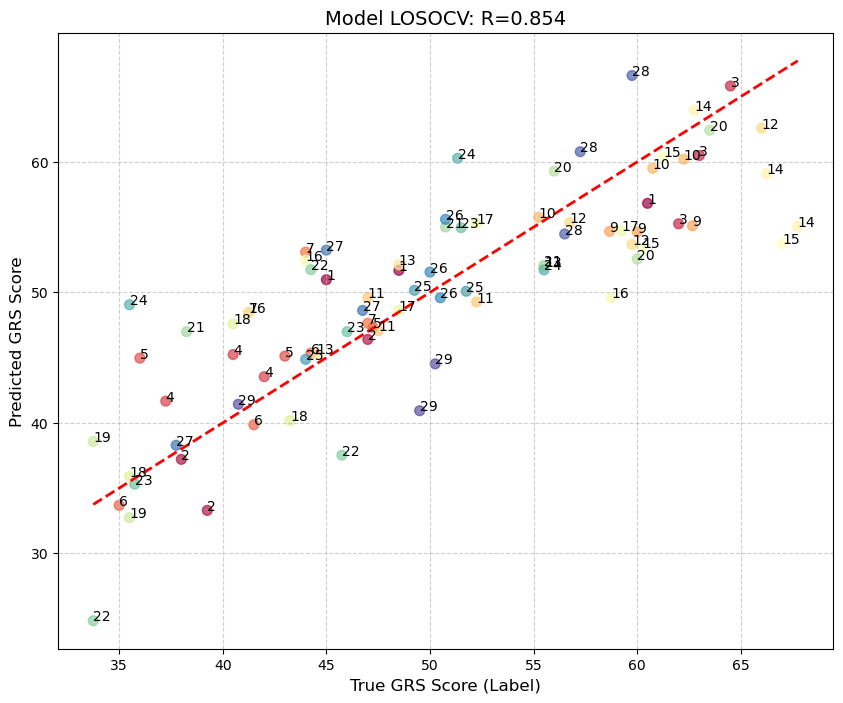

In [446]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- 1. Prepare Data (Code adapted from your input) ---

# --- IMPORTANT ASSUMPTIONS ---
# 1. merged_feature_df is available and c§orrectly indexed.
# 2. 'QRS_Overal' is the column for the true scores (y).
# 3. 'Participant Number' is the column for SurgeonID.
# 4. Feature columns are PC1, PC2, PC3, BoW_2, BoW_20.
# ------------------------------

feature_cols = [col for col in ['adjusted_total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'velocity_corr']]#, 'velocity_corr']]
additional_feature_cols = top_features #+ ['mean_abs_angle_change_Right']#['Rocket_PC27', 'Rocket_PC7', 'Rocket_PC19', 'Rocket_PC5', 'Rocket_PC24', 'Rocket_PC40']  # 'Rocket_PC25', 'Rocket_PC21', 'Rocket_PC22'
all_feature_cols = feature_cols + additional_feature_cols
X = df_combined[all_feature_cols].values
y = df_combined['QRS_Overal'].values

# Extract the Surgeon IDs for the folds
surgeon_ids = df_combined['Participant Number'].values # Assuming 'Participant Number' holds the unique surgeon/participant identifier

unique_surgeons = np.unique(surgeon_ids)
predictions = []
true_scores = []
fold_results = {} # To store results per fold

# --- 2. LOSOCV Loop ---
print(f"Starting Leave-One-Surgeon-Out CV with {len(unique_surgeons)} folds...")

# We will collect fold-level predictions for plotting
all_fold_preds = []
all_fold_true = []
all_fold_surgeons = []


for surgeon_out in tqdm(unique_surgeons, desc="LOSOCV Folds"):
    
    # Define Folds
    test_indices = np.where(surgeon_ids == surgeon_out)[0]
    train_indices = np.where(surgeon_ids != surgeon_out)[0]
    
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]

    # scale features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    
    # PCA but only on feature_cols
    pca = PCA(n_components=min(3, len(feature_cols)))  # Adjust number of components as needed
    X_train_pca = pca.fit_transform(X_train[:, :len(feature_cols)])
    X_test_pca = pca.transform(X_test[:, :len(feature_cols)])
    
    # component list to keep
    component_list = [0,1,2]  # Keep only the first principal component
    X_train_pca = X_train_pca[:, component_list]
    X_test_pca = X_test_pca[:, component_list]
    
    # Combine PCA features with additional features
    X_train = np.hstack((X_train_pca, X_train[:, len(feature_cols):]))
    X_test = np.hstack((X_test_pca, X_test[:, len(feature_cols):]))

    # 3. Train Model
    # Using the optimized alpha=0.5
    model = Ridge(alpha=0.5)                    # RidgeCV(alphas=np.logspace(-2, 4, 20)). TO CHANGE LATER
    model.fit(X_train, y_train)
    
    # Predict and store
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate Fold Metrics
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_corr, _ = pearsonr(y_test, y_test_pred)
    
    fold_results[surgeon_out] = {
        'Train_MAE': train_mae,
        'Test_MAE': test_mae,
        'Test_Corr': test_corr
    }
    
    # Store results for overall metrics and plotting
    predictions.extend(y_test_pred)
    true_scores.extend(y_test)
    all_fold_preds.extend(y_test_pred)
    all_fold_true.extend(y_test)
    all_fold_surgeons.extend([surgeon_out] * len(y_test_pred))

# --- 4. Evaluate and Print Results ---
final_predictions = np.array(predictions)
final_true_scores = np.array(true_scores)

hybrid_mae = mean_absolute_error(final_true_scores, final_predictions)
hybrid_std = np.std(np.abs(final_true_scores - final_predictions))
hybrid_corr, _ = spearmanr(final_true_scores, final_predictions)

# Create a DataFrame for per-fold results
fold_results_df = pd.DataFrame.from_dict(fold_results, orient='index')
fold_results_df.index.name = 'SurgeonID'

print("\n=================================================")
print("          HYBRID MODEL (RIDGE) LOSOCV RESULTS")
print("=================================================")
print(f"Overall Correlation (R): {hybrid_corr:.4f}")
print(f"Overall MAE: {hybrid_mae:.4f}")
print(f"Overall Std Dev of Errors: {hybrid_std:.4f}")
print(f"\n--- Per-Fold Performance Summary ---")
print(fold_results_df)

# --- 5. Visualization ---
plt.figure(figsize=(10, 8))

# Scatter plot
scatter = plt.scatter(
    all_fold_true, 
    all_fold_preds, 
    c=all_fold_surgeons, # Color by surgeon ID
    cmap='Spectral', 
    label='Predicted Scores',
    s=50,
    alpha=0.7
)

for i, sid in enumerate(surgeon_ids):
    plt.annotate(f'{sid}', (all_fold_true[i], all_fold_preds[i]))

# Diagonal Line (Perfect prediction)
plt.plot(
    [min(final_true_scores), max(final_true_scores)], 
    [min(final_true_scores), max(final_true_scores)], 
    'r--', 
    lw=2,
    label='Ideal Prediction (y=x)'
)

plt.xlabel("True GRS Score (Label)", fontsize=12)
plt.ylabel("Predicted GRS Score", fontsize=12)
plt.title(f"Model LOSOCV: R={hybrid_corr:.3f}", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Try to understand the top rocket PC

In [434]:
int(top_rocket_pc[-2:])

27

PC27 Absolute value Weights Statistics:
  Mean: 0.0036
  Std Dev: 0.0045
  Min: 0.0000
  Max: 0.0384
  Median: 0.0022
  25th Percentile: 0.0006
  75th Percentile: 0.0047
  95th Percentile: 0.0130


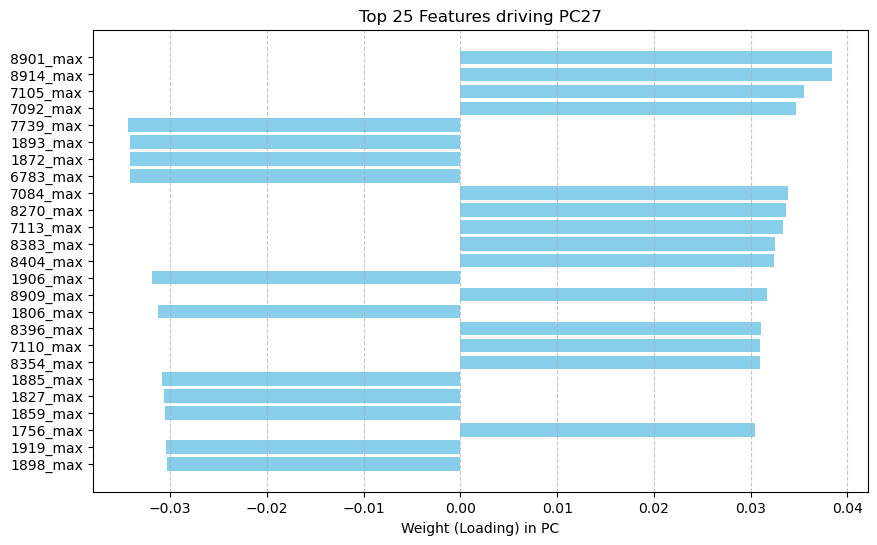

In [451]:

import matplotlib.pyplot as plt

def inspect_pca_component(pca_model, feature_names, pc_index=26, top_n=25):
    # 1. Extract the weights for the specific PC
    weights = pca_model.components_[pc_index]

    # print weights statistics
    abs_weights = np.abs(weights)
    print(f"PC{pc_index + 1} Absolute value Weights Statistics:")
    print(f"  Mean: {np.mean(abs_weights):.4f}")
    print(f"  Std Dev: {np.std(abs_weights):.4f}")
    print(f"  Min: {np.min(abs_weights):.4f}")
    print(f"  Max: {np.max(abs_weights):.4f}")
    print(f"  Median: {np.median(abs_weights):.4f}")
    print(f"  25th Percentile: {np.percentile(abs_weights, 25):.4f}")
    print(f"  75th Percentile: {np.percentile(abs_weights, 75):.4f}")
    print(f"  95th Percentile: {np.percentile(abs_weights, 95):.4f}")
    
    # 2. Get the absolute values to find the "most influential" regardless of direction
    abs_weights = np.abs(weights)
    
    # 3. Sort and get top N indices
    top_indices = np.argsort(abs_weights)[::-1][:top_n]
    
    # 4. Create a summary dataframe
    top_features = []
    for idx in top_indices:
        top_features.append({
            'Feature': feature_names[idx],
            'Weight': weights[idx],
            'AbsWeight': abs_weights[idx]
        })
    
    df_top = pd.DataFrame(top_features)
    
    # 5. Visualize
    plt.figure(figsize=(10, 6))
    plt.barh(df_top['Feature'], df_top['Weight'], color='skyblue')
    plt.xlabel('Weight (Loading) in PC')
    plt.title(f'Top {top_n} Features driving PC{pc_index + 1}')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()
    
    return df_top

# Usage:
df_top_kernels = inspect_pca_component(pca_rocket, video_level_rocket.columns, pc_index=26, top_n=25)#int(top_rocket_pc[-2:])-1)

In [436]:
df_top_kernels

,Feature,Weight,AbsWeight
0,8901_max,0.038445,0.038445
1,8914_max,0.038445,0.038445
2,7105_max,0.035472,0.035472
3,7092_max,0.034695,0.034695
4,7739_max,-0.034392,0.034392
5,1893_max,-0.034209,0.034209
6,1872_max,-0.034209,0.034209
7,6783_max,-0.034157,0.034157
8,7084_max,0.033868,0.033868
9,8270_max,0.033617,0.033617


In [437]:
def get_minirocket_props_v2(rocket_model):
    """
    Attempts to find the dilation and channel indices across different sktime versions.
    """
    # 1. Try to find the transformer object
    # Often it's stored in self.transformer_ or self.minirocket_
    if hasattr(rocket_model, "transformer_"):
        inner = rocket_model.transformer_
    elif hasattr(rocket_model, "_transformer"):
        inner = rocket_model._transformer
    else:
        inner = rocket_model

    # 2. Access dilations and features per dilation
    try:
        # Some versions use .dilations, others ._dilations, others .parameters
        dilations = getattr(inner, "dilations", None)
        num_features = getattr(inner, "num_features_per_dilation", None)
        
        if dilations is None and hasattr(inner, "parameters"):
            # If it's the raw parameter tuple (dilations, num_features_per_dilation, ...)
            dilations = inner.parameters[0]
            num_features = inner.parameters[1]
            
        return dilations, num_features
    except Exception as e:
        print(f"Could not extract: {e}")
        return None, None

# Let's apply it to your Top PC
dilations, num_features_per_dilation = get_minirocket_props_v2(rocket)

if dilations is not None:
    # 3. Backtrack the feature index
    # (top_idx // 3) because each kernel has Mean, Max, Std
    kernel_idx = top_idx // 3
    cumulative_features = np.cumsum(num_features_per_dilation)
    dilation_group = np.searchsorted(cumulative_features, kernel_idx)
    
    expert_dilation = dilations[dilation_group]
    print(f"✅ Success! Expert Kernel Dilation: {expert_dilation} frames")
    print(f"Physical meaning: This kernel 'sees' patterns over {expert_dilation/10:.2f} seconds.")
else:
    # If the above still fails, we can use a "Brute Force" check
    print("❌ Attributes still hidden. Try: dir(rocket) to see available names.")

IndexError: index 421 is out of bounds for axis 0 with size 252

In [ ]:
def analyze_expert_kernels(rocket_model, pca_model, pc_index=27, top_k=3):
    """
    Extracts the underlying MiniRocket parameters for the kernels
    that dominate a specific PCA component.
    """
    # 1. Get loadings and find top kernels
    # Note: If your features are [K1_mean, K1_max, K1_std...], 
    # the kernel index is floor(feature_index / 3)
    weights = pca_model.components_[pc_index]
    top_feature_indices = np.argsort(np.abs(weights))[::-1][:top_k]
    
    print(f"--- Analysis of Top {top_k} Kernels for PC{pc_index+1} ---")
    
    for feat_idx in top_feature_indices:
        kernel_idx = feat_idx // 3 # Adjust based on your actual feature column order
        agg_type = ['mean', 'max', 'std'][feat_idx % 3]
        weight = weights[feat_idx]
        
        # Access parameters from MiniRocket
        # MiniRocket uses 84 fixed patterns; we find which one this kernel uses
        # Note: Depending on your sktime version, parameter access might vary
        dilation = rocket_model.dilations_[kernel_idx]
        num_features_per_dilation = rocket_model.num_features_per_dilation_
        
        print(f"\nFeature: Kernel_{kernel_idx}_{agg_type}")
        print(f"Weight in PC: {weight:.4f}")
        print(f"Dilation (Scale): {dilation} frames (~{dilation/10:.2f} seconds)")
        
        # Visualize the pattern (Conceptual - MiniRocket uses PPV of 84 linear patterns)
        # We can plot a synthetic version of the 'Expert' motion this kernel likes
    
    return top_feature_indices

top_indices = analyze_expert_kernels(rocket, pca_rocket)

--- Analysis of Top 3 Kernels for PC28 ---


AttributeError: 'MiniRocketMultivariate' object has no attribute 'dilations_'